In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Load the bank marketing dataset.

In [2]:
df = pd.read_csv('bank.csv')


In [3]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


2. Clean the data and handle missing values.

In [4]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [6]:
counts = df.eq('unknown').sum()
print(counts[counts>0])

job            70
education     497
contact      2346
poutcome     8326
dtype: int64


In [7]:
df['accepted'] = (df['deposit'] == 'yes').astype(int)

In [8]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,accepted
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,1
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,1
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,1
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,1
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no,0
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no,0
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no,0
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,0


3. Calculate the overall acceptance rate of the offer.

In [13]:
rate = df['accepted'].mean()
print(f"Rate: {rate: .2%}")

Rate:  47.38%


4. Compare average age and balance of those who accepted vs. rejected.

In [14]:
age_balance = df.groupby('deposit')[['age', 'balance']].mean()
print(age_balance)

               age      balance
deposit                        
no       40.837391  1280.227141
yes      41.670070  1804.267915


5. Analyze acceptance rate by marital status.

In [ ]:
analysis = df.groupby('marital')['accepted'].mean().reset_index()
analysis = analysis.sort_values(by='accepted')
print(analysis)

    marital  accepted
1   married  0.433790
0  divorced  0.481052
2    single  0.543491


6. Analyze acceptance rate by education level.

In [19]:
education = df.groupby('education')['accepted'].mean().reset_index()
education = education.sort_values(by='accepted')
print(education)

   education  accepted
0    primary  0.394000
1  secondary  0.447407
3    unknown  0.507042
2   tertiary  0.541068


7. Create a bar chart showing acceptance by job type.

In [21]:
job = df.groupby('job')['accepted'].mean().reset_index()
job = job.sort_values(by = 'accepted')
print(job)

              job  accepted
1     blue-collar  0.364198
2    entrepreneur  0.375000
3       housemaid  0.397810
7        services  0.399783
9      technician  0.460779
6   self-employed  0.461728
0          admin.  0.473013
11        unknown  0.485714
4      management  0.507015
10     unemployed  0.565826
5         retired  0.663239
8         student  0.747222


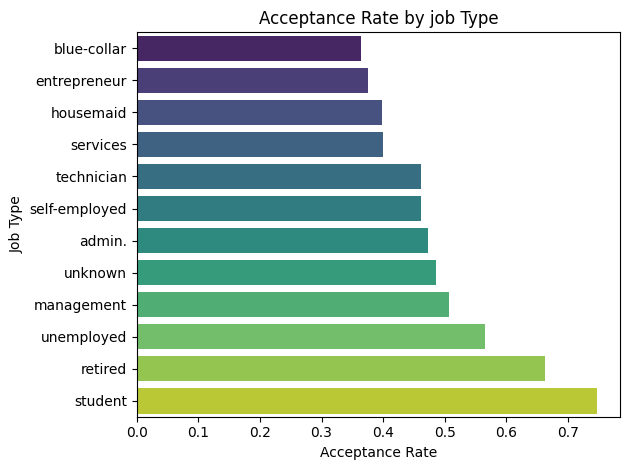

In [ ]:
plt.Figure(figsize=(10,6))
sns.barplot(x='accepted', y ='job', data=job, palette='viridis', hue='job', legend=False)
plt.title('Acceptance Rate by job Type')
plt.xlabel('Acceptance Rate')
plt.ylabel('Job Type')
plt.tight_layout()
plt.show()

8. Visualize the age distribution of accepting customers.

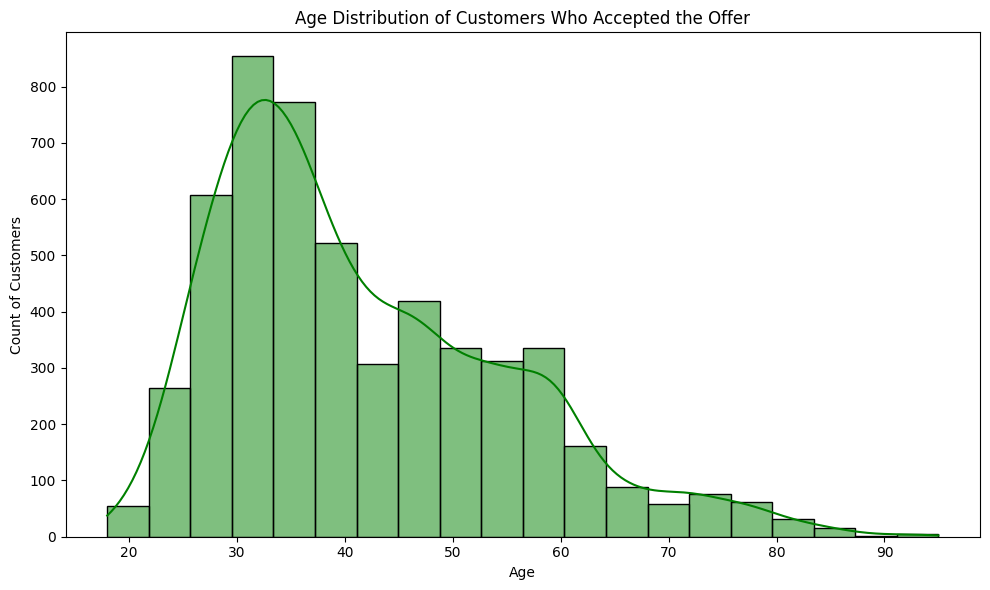

In [25]:
accepted_customers = df[df['deposit'] == 'yes']

plt.figure(figsize=(10, 6))
sns.histplot(accepted_customers['age'], bins=20, kde=True, color='green')
plt.title('Age Distribution of Customers Who Accepted the Offer')
plt.xlabel('Age')
plt.ylabel('Count of Customers')
plt.tight_layout()
plt.show()

9. Identify the primary traits of customers who accepted the offer.

In [26]:
print("Demographics Summary for Accepting Customers")
print(accepted_customers[['age', 'balance']].describe())

print("\nTop Categories for Accepting Customers")
print(f"Top Job: {accepted_customers['job'].mode()[0]}")
print(f"Top Marital Status: {accepted_customers['marital'].mode()[0]}")
print(f"Top Education: {accepted_customers['education'].mode()[0]}")

Demographics Summary for Accepting Customers
               age       balance
count  5289.000000   5289.000000
mean     41.670070   1804.267915
std      13.497781   3501.104777
min      18.000000  -3058.000000
25%      31.000000    210.000000
50%      38.000000    733.000000
75%      50.000000   2159.000000
max      95.000000  81204.000000

Top Categories for Accepting Customers
Top Job: management
Top Marital Status: married
Top Education: secondary


10. Summarize recommendations for future marketing campaigns.

In [ ]:
print("""
MARKETING CAMPAIGN RECOMMENDATIONS
1. Target High-Balance Accounts: Customers who accepted had an average balance (~$1804) 
   significantly higher than those who rejected (~$1280). Focus on more affluent demographics.
2. Prioritize Students and Retirees: These job types had the highest conversion rates (74.7% and 66.3%). 
   Design specific sub-campaigns addressing student savings goals and retirement security.
3. Align Content with Higher Education: Tertiary-educated segments are much more receptive (54.1%) 
   compared to primary-educated segments (39.4%). Keep campaign copies polished and professional.
4. Customize Offerings for Single Individuals: Single individuals convert at a higher rate (54.3%) 
   than married individuals (43.4%), making them high-value targets for direct advertising.
""")


MARKETING CAMPAIGN RECOMMENDATIONS
1. Target High-Balance Accounts: Customers who accepted had an average balance (~$1804) 
   significantly higher than those who rejected (~$1280). Focus on more affluent demographics.
2. Prioritize Students and Retirees: These job types had the highest conversion rates (74.7% and 66.3%). 
   Design specific sub-campaigns addressing student savings goals and retirement security.
3. Align Content with Higher Education: Tertiary-educated segments are much more receptive (54.1%) 
   compared to primary-educated segments (39.4%). Keep campaign copies polished and professional.
4. Customize Offerings for Single Individuals: Single individuals convert at a higher rate (54.3%) 
   than married individuals (43.4%), making them high-value targets for direct advertising.

